Dataset Shape: (7043, 21)

--- Summary Statistics ---
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7041.000000
mean        0.162147    32.371149       64.749581
std         0.368612    24.559481       30.085731
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


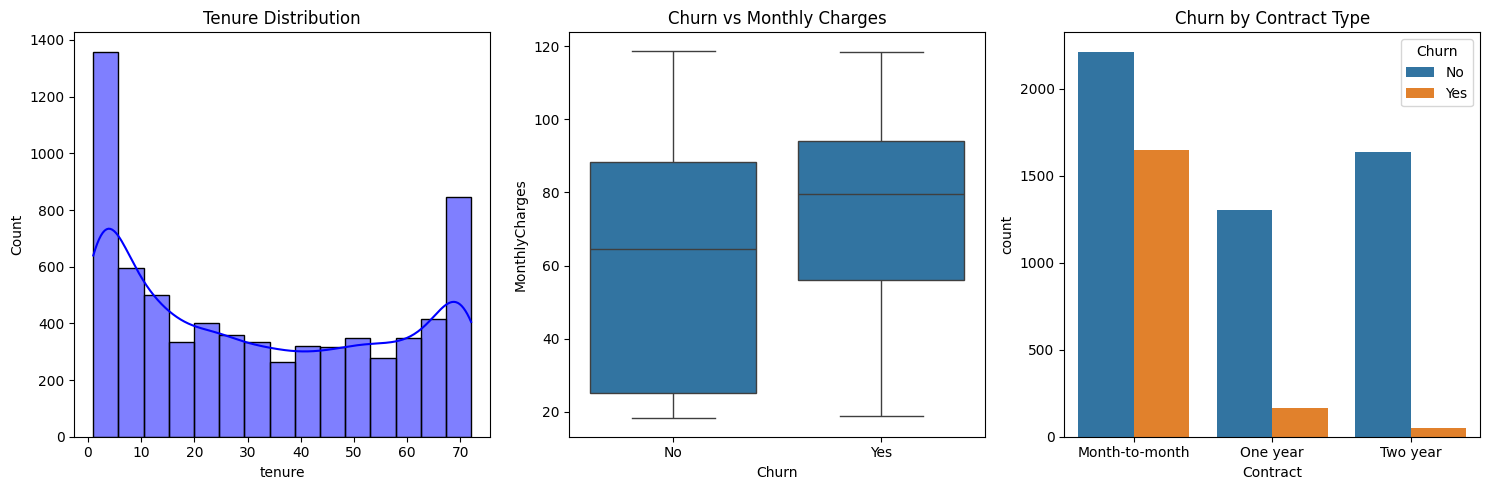

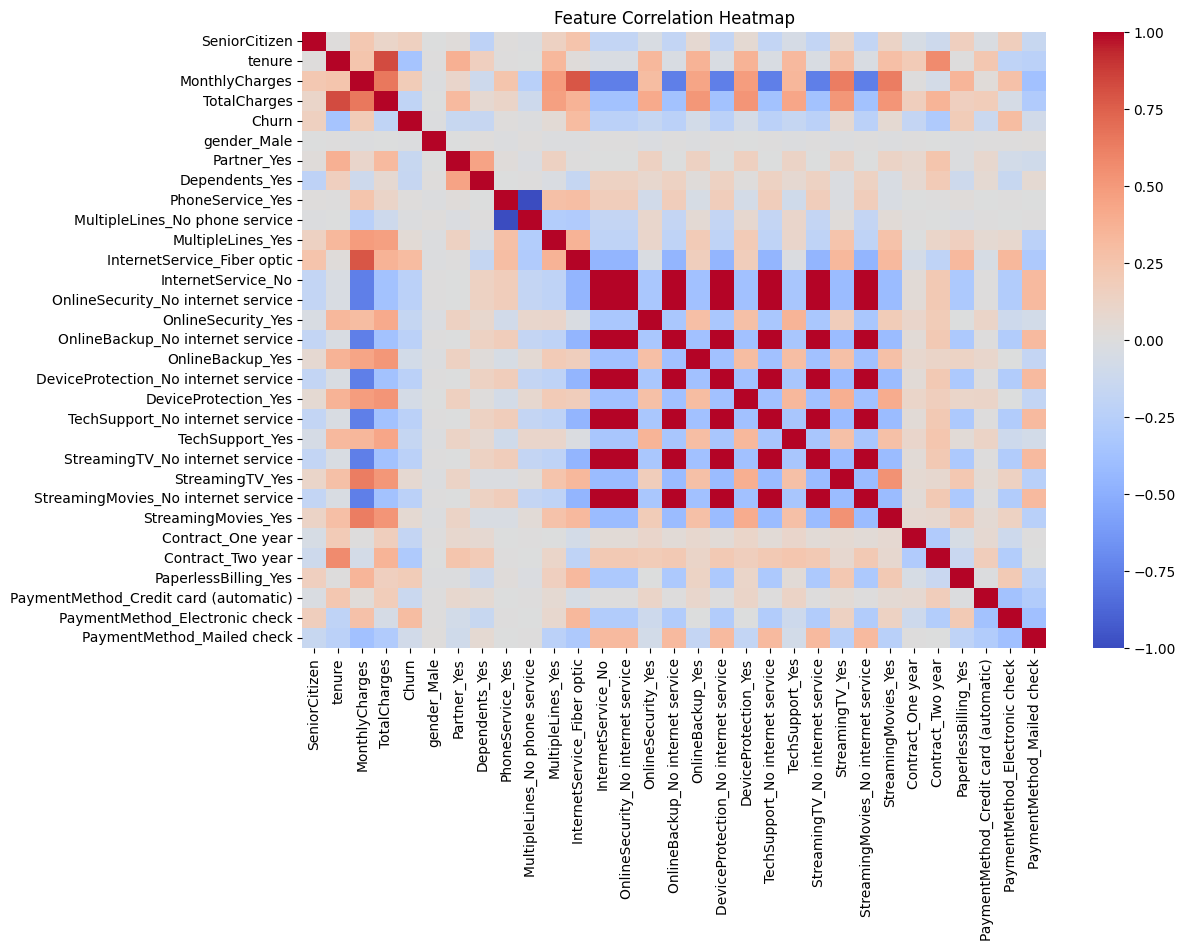


--- Model Comparison ---
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
5    Gradient Boosting  0.781339   0.578571  0.651475  0.612863  0.840442
0  Logistic Regression  0.786325   0.594315  0.616622  0.605263  0.837972
4                  SVC  0.789174   0.602667  0.605898  0.604278  0.812864
6              XGBoost  0.796296   0.626822  0.576408  0.600559  0.823476
3        Random Forest  0.783476   0.597183  0.568365  0.582418  0.827937
1                  KNN  0.720798   0.481481  0.662198  0.557562  0.768216
2        Decision Tree  0.745014   0.518797  0.554960  0.536269  0.688088

Best Model Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}

--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1031
           1       0.57      0.68      0.62       373

    accuracy                           0.78      1404
   macro avg       0.72      0.75      0.7

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')


df = pd.read_csv('telecom_churn_data.csv')


print(f"Dataset Shape: {df.shape}")
print("\n--- Summary Statistics ---")
print(df.describe())


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
if 'customerID' in df.columns: df.drop(columns=['customerID'], inplace=True)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['tenure'], kde=True, color='blue').set_title('Tenure Distribution')
plt.subplot(1, 3, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df).set_title('Churn vs Monthly Charges')
plt.subplot(1, 3, 3)
sns.countplot(x='Contract', hue='Churn', data=df).set_title('Churn by Contract Type')
plt.tight_layout()
plt.show()


for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)


le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])
df = pd.get_dummies(df, drop_first=True) # One-Hot Encoding


plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name, "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred), "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred), "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


comparison_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
print("\n--- Model Comparison ---")
print(comparison_df)


param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]}
grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train_res, y_train_res)


best_model = grid.best_estimator_
final_pred = best_model.predict(X_test)
print(f"\nBest Model Parameters: {grid.best_params_}")
print("\n--- Final Classification Report ---")
print(classification_report(y_test, final_pred))

print("\n--- 💡 Business Recommendations ---")
print("1. Target Month-to-Month contract holders with long-term discounts.")
print("2. Focus on customers with high monthly charges for personalized loyalty rewards.")
print("3. Ensure Fiber Optic customers receive enhanced technical support to reduce friction.")